In [46]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

In [47]:
model_df = pd.read_csv("../data/model_df.csv")

In [48]:
model_df.head()

,funding_total_usd,funding_rounds,funding_duration_days,avg_funding_per_round,market_sector,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,product_crowdfunding,status
0,1750000.0,1,0,1750000.0,Media & Entertainment,1750000,0,0,0,0,0,0,0,0,0,acquired
1,4912393.0,1,0,4912393.0,Advertising & Marketing,0,0,0,4912393,0,0,0,0,0,0,closed
2,500000.0,1,0,500000.0,E-commerce & Retail,500000,0,0,0,0,0,0,0,0,0,acquired
3,2535000.0,2,411,1267500.0,Software & Cloud,15000,2520000,0,0,0,0,0,0,0,0,acquired
4,1250000.0,2,28,625000.0,AI & Data,750000,500000,0,0,0,0,0,0,0,0,acquired


In [49]:
model_df["log_funding_total_usd"] = np.log1p(
    model_df["funding_total_usd"]
)

In [50]:
selected_features = [
    "log_funding_total_usd",
    "funding_rounds",
    "funding_duration_days",
    "avg_funding_per_round",
    "market_sector",
    "seed",
    "venture",
    "equity_crowdfunding",
    "undisclosed",
    "convertible_note",
    "debt_financing",
    "angel",
    "grant",
    "private_equity",
    "product_crowdfunding"
]

X = model_df[selected_features]

y = model_df["status"]

In [51]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))

{'acquired': np.int64(0), 'closed': np.int64(1)}


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [53]:
categorical_features = [
    "market_sector"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

#### Logistic Regression Preprocessing

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

#### Preprocessing for XGBoost/ Random Forest

In [55]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logistic_pipeline = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [57]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # ==========================
    # Train Model
    # ==========================
    model.fit(X_train, y_train)

    # ==========================
    # Predictions
    # ==========================
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # ==========================
    # Evaluation Metrics
    # ==========================
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # ==========================
    # Confusion Matrix
    # ==========================
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ==========================
    # ROC Curve
    # ==========================
    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title(f"{model_name} - ROC Curve")
    plt.show()

    # ==========================
    # Return metrics
    # ==========================
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

Logistic Regression
Accuracy : 0.6966
Precision: 0.6865
Recall   : 0.4885
F1 Score : 0.5708
ROC-AUC  : 0.7366

Classification Report

              precision    recall  f1-score   support

           0       0.70      0.84      0.77       739
           1       0.69      0.49      0.57       520

    accuracy                           0.70      1259
   macro avg       0.69      0.67      0.67      1259
weighted avg       0.69      0.70      0.68      1259



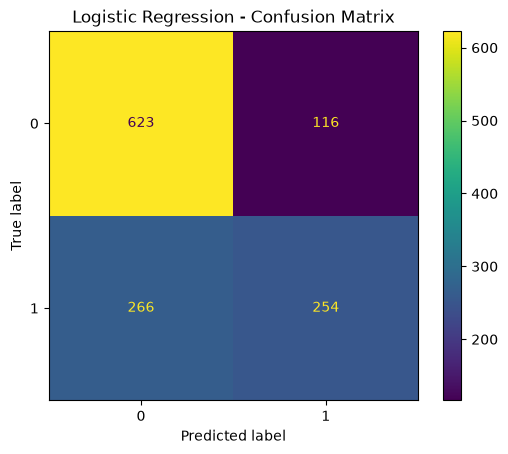

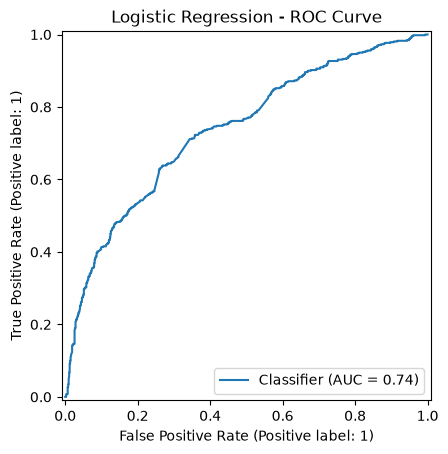

In [58]:
lr_results = evaluate_model(
    logistic_pipeline,
    X_train,
    X_test,
    y_train,
    y_test,
    "Logistic Regression"
)

Random Forest
Accuracy : 0.6759
Precision: 0.6167
Recall   : 0.5692
F1 Score : 0.5920
ROC-AUC  : 0.7071

Classification Report

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       739
           1       0.62      0.57      0.59       520

    accuracy                           0.68      1259
   macro avg       0.66      0.66      0.66      1259
weighted avg       0.67      0.68      0.67      1259



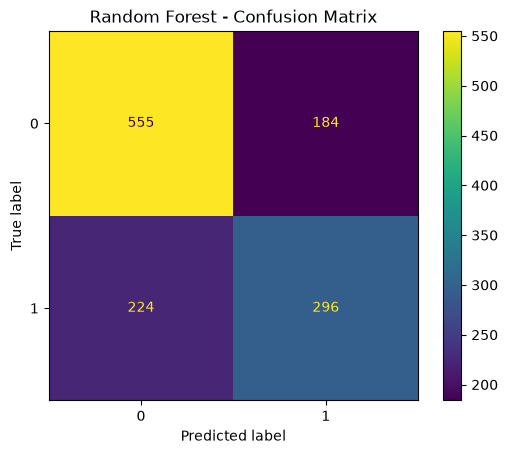

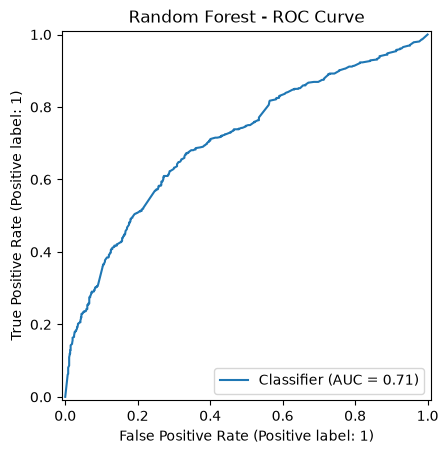

In [59]:
rf_results = evaluate_model(
    rf_pipeline,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)

XGBoost
Accuracy : 0.6910
Precision: 0.6329
Recall   : 0.6000
F1 Score : 0.6160
ROC-AUC  : 0.7325

Classification Report

              precision    recall  f1-score   support

           0       0.73      0.76      0.74       739
           1       0.63      0.60      0.62       520

    accuracy                           0.69      1259
   macro avg       0.68      0.68      0.68      1259
weighted avg       0.69      0.69      0.69      1259



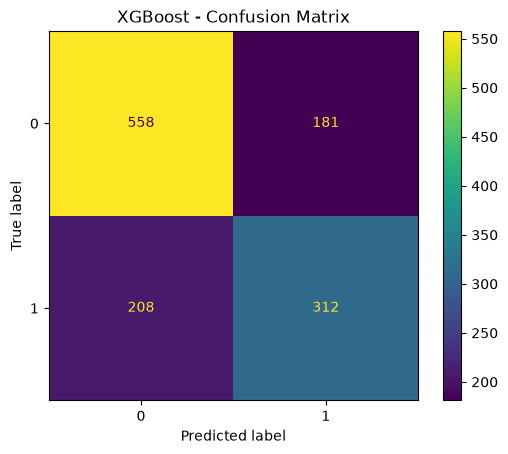

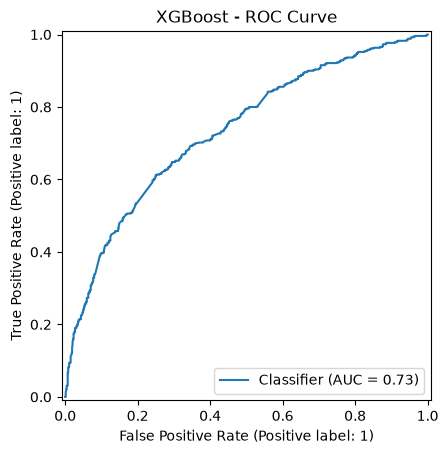

In [60]:
xgb_results = evaluate_model(
    xgb_pipeline,
    X_train,
    X_test,
    y_train,
    y_test,
    "XGBoost"
)

In [61]:
comparison = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

comparison.sort_values(
    by="ROC-AUC",
    ascending=False,
    inplace=True
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.696585,0.686486,0.488462,0.570787,0.736632
2,XGBoost,0.691025,0.632860,0.600000,0.615992,0.732530
1,Random Forest,0.675933,0.616667,0.569231,0.592000,0.707113


In [62]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [63]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [64]:
lr_cv = cross_validate(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

xgb_cv = cross_validate(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)


comparison_cv = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],

    "Accuracy Mean": [
        lr_cv["test_accuracy"].mean(),
        xgb_cv["test_accuracy"].mean()
    ],

    "Accuracy Std": [
        lr_cv["test_accuracy"].std(),
        xgb_cv["test_accuracy"].std()
    ],

    "Precision Mean": [
        lr_cv["test_precision"].mean(),
        xgb_cv["test_precision"].mean()
    ],

    "Recall Mean": [
        lr_cv["test_recall"].mean(),
        xgb_cv["test_recall"].mean()
    ],

    "F1 Mean": [
        lr_cv["test_f1"].mean(),
        xgb_cv["test_f1"].mean()
    ],

    "ROC-AUC Mean": [
        lr_cv["test_roc_auc"].mean(),
        xgb_cv["test_roc_auc"].mean()
    ],

    "ROC-AUC Std": [
        lr_cv["test_roc_auc"].std(),
        xgb_cv["test_roc_auc"].std()
    ]
})

comparison_cv = comparison_cv.round(4)

comparison_cv

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.6937,0.0133,0.6883,0.4735,0.5608,0.7396,0.0137
1,XGBoost,0.6860,0.0093,0.6452,0.5400,0.5867,0.7311,0.0158


In [65]:
roc_auc_folds = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Logistic Regression": lr_cv["test_roc_auc"],
    "XGBoost": xgb_cv["test_roc_auc"]
})

roc_auc_folds

,Fold,Logistic Regression,XGBoost
0,1,0.724556,0.734350
1,2,0.723005,0.711099
2,3,0.755182,0.758409
3,4,0.753333,0.721933
4,5,0.741956,0.729616


## Hypertune the Logistic Regression Model

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [67]:
lr_pipeline = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=5000
    ))
])

In [68]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

In [69]:
grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


d:\COLLEGE\DAIICT\Project\Startup-Closing-Analysis-\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_

In [70]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Best CV ROC-AUC:
0.7394


d:\COLLEGE\DAIICT\Project\Startup-Closing-Analysis-\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Tuned Logistic Regression
Accuracy : 0.7021
Precision: 0.6975
Recall   : 0.4923
F1 Score : 0.5772
ROC-AUC  : 0.7384

Classification Report

              precision    recall  f1-score   support

           0       0.70      0.85      0.77       739
           1       0.70      0.49      0.58       520

    accuracy                           0.70      1259
   macro avg       0.70      0.67      0.67      1259
weighted avg       0.70      0.70      0.69      1259



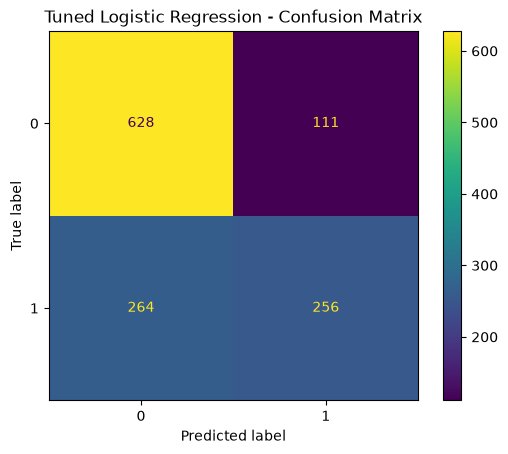

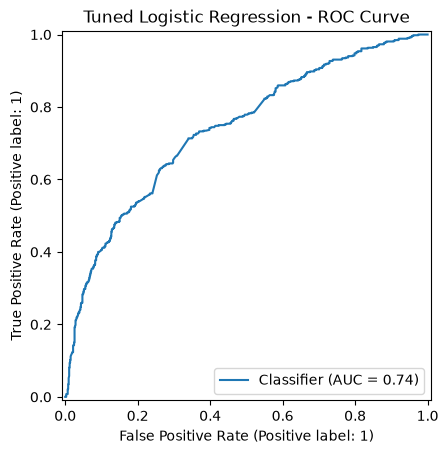

In [73]:
best_model = grid_search.best_estimator_

results = evaluate_model(
    best_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Tuned Logistic Regression"
)

In [74]:
comparison = pd.DataFrame([
    {
        "Model": "Baseline Logistic Regression",
        "Accuracy": lr_results["Accuracy"],
        "Precision": lr_results["Precision"],
        "Recall": lr_results["Recall"],
        "F1 Score": lr_results["F1 Score"],
        "ROC-AUC": lr_results["ROC-AUC"]
    },
    {
        "Model": "Tuned Logistic Regression",
        "Accuracy": results["Accuracy"],
        "Precision": results["Precision"],
        "Recall": results["Recall"],
        "F1 Score": results["F1 Score"],
        "ROC-AUC": results["ROC-AUC"]
    }
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.696585,0.686486,0.488462,0.570787,0.736632
1,Tuned Logistic Regression,0.702145,0.697548,0.492308,0.577227,0.738360


In [75]:
best_lr = grid_search.best_estimator_

preprocessor = best_lr.named_steps["preprocessor"]
classifier = best_lr.named_steps["classifier"]

In [76]:
feature_names = preprocessor.get_feature_names_out()

In [88]:
import pandas as pd
import numpy as np

# Best tuned pipeline
best_model = grid_search.best_estimator_

# Extract fitted preprocessor and logistic regression model
preprocessor = best_model.named_steps["preprocessor"]
classifier = best_model.named_steps["classifier"]

In [89]:
feature_names = preprocessor.get_feature_names_out()

In [90]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": classifier.coef_[0]
})

In [91]:
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])

In [92]:
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

In [94]:
coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
).reset_index(drop=True)

coef_df.round(2)

,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
0,num__log_funding_total_usd,-0.91,0.40,0.91
1,cat__market_sector_AI & Data,-0.68,0.50,0.68
2,cat__market_sector_Security,-0.34,0.71,0.34
3,cat__market_sector_E-commerce & Retail,0.28,1.32,0.28
4,num__funding_duration_days,-0.25,0.78,0.25
5,cat__market_sector_Media & Entertainment,0.25,1.28,0.25
6,cat__market_sector_Other,-0.25,0.78,0.25
7,cat__market_sector_Social & Community,0.24,1.27,0.24
8,cat__market_sector_Healthcare & Biotech,0.23,1.26,0.23
9,cat__market_sector_Travel & Hospitality,-0.20,0.82,0.20


In [101]:
coef_original = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": classifier.coef_[0]
})

coef_original["Odds_Ratio"] = np.exp(coef_original["Coefficient"])
coef_original["Abs_Coefficient"] = coef_original["Coefficient"].abs()

In [102]:
importance_df = coef_original.copy()

importance_df["Feature"] = importance_df["Feature"].apply(
    lambda x: "Market Sector"
    if x.startswith("cat__market_sector")
    else x.replace("num__", "")
)

importance_df = (
    importance_df.groupby("Feature")["Abs_Coefficient"]
    .sum()
    .reset_index()
)

importance_df["Importance (%)"] = (
    importance_df["Abs_Coefficient"] /
    importance_df["Abs_Coefficient"].sum()
) * 100

importance_df = importance_df.sort_values(
    by="Importance (%)",
    ascending=False
)

importance_df

,Feature,Abs_Coefficient,Importance (%)
0,Market Sector,3.559165,66.052732
9,log_funding_total_usd,0.905350,16.801939
6,funding_duration_days,0.252976,4.694856
14,venture,0.146825,2.724849
5,equity_crowdfunding,0.139965,2.597535
3,convertible_note,0.084059,1.560006
7,funding_rounds,0.059990,1.113332
12,seed,0.048775,0.905190
11,product_crowdfunding,0.046486,0.862702
8,grant,0.039674,0.736281


In [ ]:
market_sector_df = coef_original[
    coef_original["Feature"].str.startswith("cat__market_sector")
].copy()

market_sector_df["Feature"] = (
    market_sector_df["Feature"]
    .str.replace("cat__market_sector_", "", regex=False)
)

market_sector_df = market_sector_df.sort_values(
    by="Coefficient",
    ascending=True
)

market_sector_df[
    ["Feature", "Coefficient", "Odds_Ratio"]
]

,Feature,Coefficient,Odds_Ratio
14,AI & Data,-0.684888,0.504147
29,Security,-0.335655,0.714870
27,Other,-0.246694,0.781380
33,Travel & Hospitality,-0.199551,0.819099
21,Financial Services,-0.165089,0.847818
19,Education,-0.116242,0.890260
20,Energy & Environment,-0.087373,0.916335
28,Real Estate,-0.077445,0.925478
16,Business Services,-0.076593,0.926266
17,Consumer & Lifestyle,-0.019282,0.980902


: 